In [1]:
import os
import sys
import tqdm
current_directory = os.getcwd()
upper_directory = os.path.abspath(os.path.join(current_directory, ".."))
sys.path.append(upper_directory)


## ================================================================= ##

import torch
import numpy as np
import yaml

from model.KS_model import KS_foward_model, KS_inv_obs_model
from utils import dict2namespace
from var_opt.Tensor_Var import Tensor_Var


import matplotlib.pyplot as plt

In [2]:
working_dir = "../training_scripts/KS_D128"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("[INFO] Using {} device".format(device))
print("[INFO] ", torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU')

config_path = os.path.join(working_dir, 'config.yaml')
with open(config_path, 'r') as file:
    config = yaml.safe_load(file)
config = dict2namespace(config)

[INFO] Using cuda device
[INFO]  _CudaDeviceProperties(name='NVIDIA GeForce RTX 4090', major=8, minor=9, total_memory=24195MB, multi_processor_count=128)


In [3]:
# Set the parameters
n_state = 128
n_obs = int(n_state * 0.2)

ass_w = 3 # assimilation window 
ass_T = ass_w * 20

num_mc = 10 # number of repeated experiments

In [4]:
# Load models
forward_model = KS_foward_model(config)
forward_model.load_state_dict(torch.load(working_dir + '/model_weights/forward_model.pt', map_location="cpu"))
forward_model.C_fwd = torch.load(working_dir + '/model_weights/C_fwd.pt', map_location="cpu")

inv_obs_model = KS_inv_obs_model(config)
inv_obs_model.load_state_dict(torch.load(working_dir + '/model_weights/inv_obs_model.pt', map_location="cpu"))

# Load error covariance matrices
try:
    Q = torch.load(working_dir + '/' + 'Q.pt', map_location="cpu")
    R = torch.load(working_dir + '/' + 'R.pt', map_location="cpu")
    B = torch.load(working_dir + '/' + 'B.pt', map_location="cpu")
except:
    hidden_dim = forward_model.hidden_dim
    B = np.eye(hidden_dim) * 0.1
    R = np.eye(hidden_dim) 
    Q = np.eye(hidden_dim) * 0.1

DA_Tensor_Var = Tensor_Var(forward_model=forward_model, 
                            observation_model=inv_obs_model, 
                            n_state=n_state, 
                            n_obs=n_obs,
                            B=B,
                            Q=Q,
                            R=R)

[INFO] Positional Encoding is used
[INFO] Input size of the fully connected layer:  896
[INFO] Freezing phi_S
[INFO] Freezing phi_inv_S


/tmp/ipykernel_2132866/2047594556.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  forward_model.load_state_dict(torch.load(working_dir + '/model_weights/forward_model.pt

In [5]:
# Load data
data_save_path = '../data/KS_data_dim128'
test_seq_state = np.load(data_save_path + '/test_seq_state.npy', mmap_mode='r')[:, 500:, ...]
test_seq_obs = np.load(data_save_path + '/test_seq_obs.npy', mmap_mode='r')[:, 500:, ...]
test_seq_hist = np.load(data_save_path + '/test_seq_hist.npy', mmap_mode='r')[:, 500:, ...]

max_value = test_seq_state.max()
min_value = test_seq_state.min()
z_b = torch.load(working_dir + '/model_weights/z_b.pt', map_location="cpu")

test_seq_state = test_seq_state[:num_mc]
test_seq_obs = test_seq_obs[:num_mc]
test_seq_hist = test_seq_hist[:num_mc]

/tmp/ipykernel_2132866/243970983.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  z_b = torch.load(working_dir + '/model_weights/z_b.pt', map_location="cpu")


[INFO] Assimilation Window Length: 3
[INFO] Traj Length: 60


DA Evaulation:   0%|          | 0/10 [00:00<?, ?it/s]/home/yiming/Documents/Yiming/Tensor-Var/var_opt/Tensor_Var.py:77: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at ../torch/csrc/utils/tensor_numpy.cpp:206.)
  hist = torch.Tensor(seq_hist[start:end]).permute(0, 2, 1)
DA Evaulation:  10%|█         | 1/10 [00:04<00:36,  4.02s/it]

[INFO] 0th traj Estimation Error: 0.10481906760114419


DA Evaulation:  20%|██        | 2/10 [00:08<00:32,  4.05s/it]

[INFO] 1th traj Estimation Error: 0.10709257073391998


...

[INFO] 7th traj Estimation Error: 0.09752151024126784


DA Evaulation:  90%|█████████ | 9/10 [00:36<00:04,  4.08s/it]

[INFO] 8th traj Estimation Error: 0.11010141758058821


DA Evaulation: 100%|██████████| 10/10 [00:40<00:00,  4.08s/it]


[INFO] 9th traj Estimation Error: 0.10422467784997078


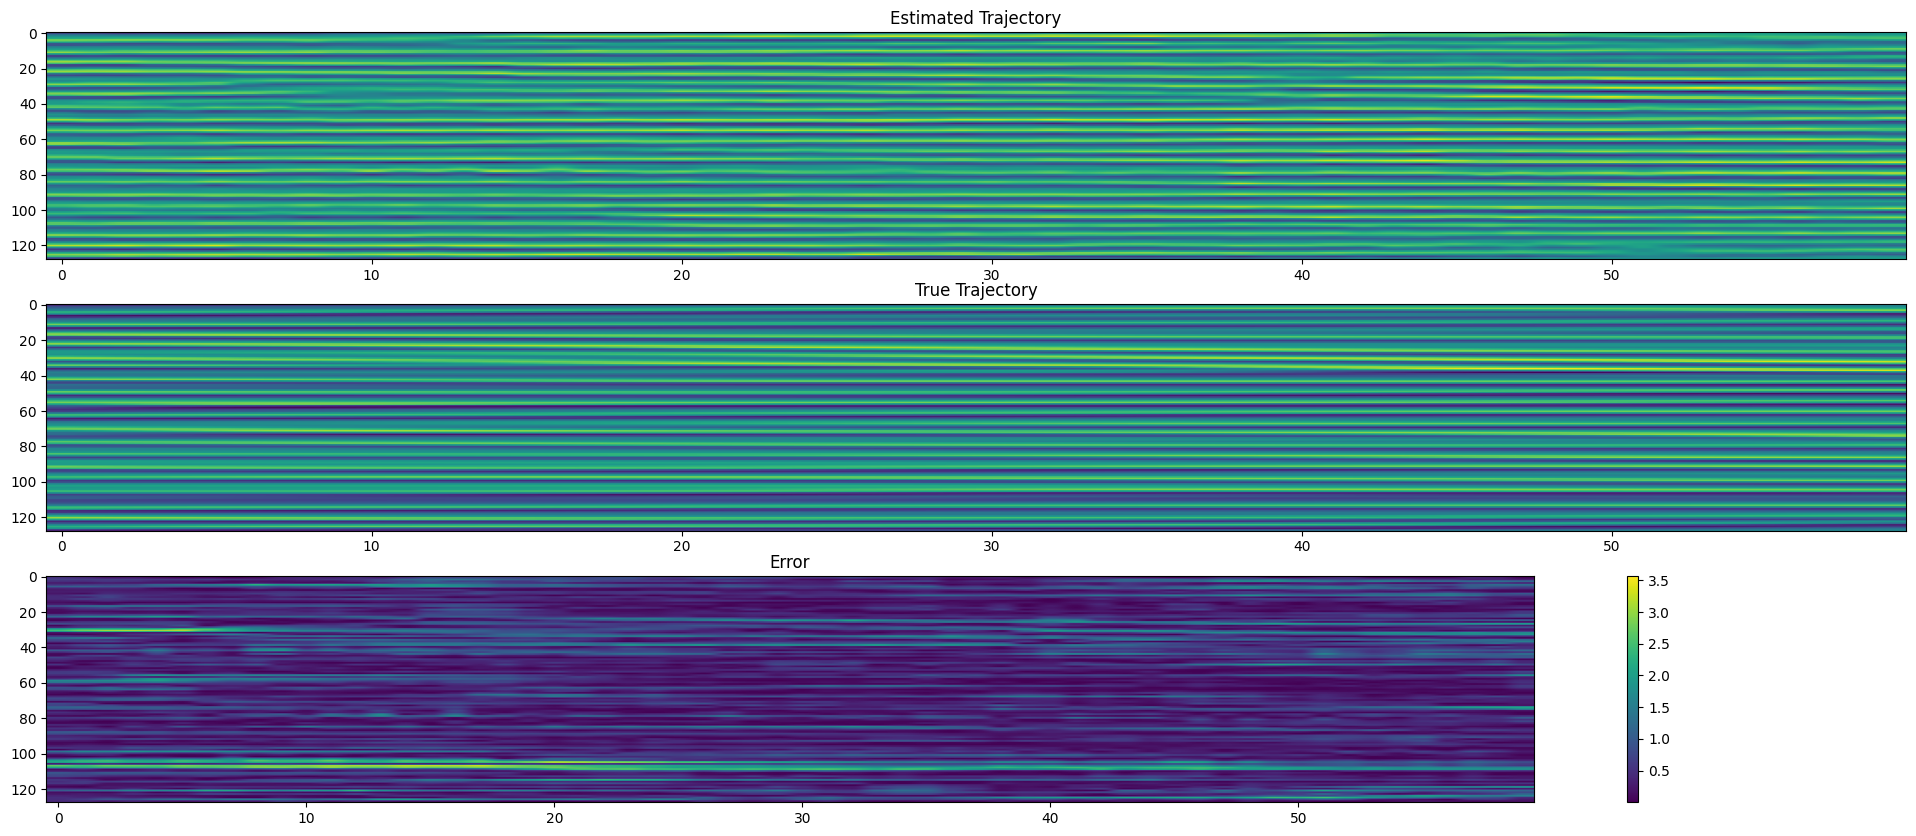

In [6]:
error_list = np.zeros(num_mc)
time_list = np.zeros(num_mc)
max_value = test_seq_state.max() 
min_value = test_seq_state.min() 
print("[INFO] Assimilation Window Length: {}".format(ass_w))
print("[INFO] Traj Length: {}".format(ass_T))
for i in tqdm.tqdm(range(num_mc), desc="DA Evaulation"):
    traj_true = test_seq_state[i, :ass_T]
    traj_estimation, eval_time = DA_Tensor_Var.perform_4DVar(test_seq_obs[i], 
                                                             seq_hist=test_seq_hist[i], 
                                                             z_b=z_b, 
                                                             assimilation_window=ass_w, 
                                                             T=ass_T)
    rmse = np.sqrt( np.mean( (np.array(traj_estimation) - traj_true)**2) )/(max_value-min_value)
    error_list[i] = rmse
    time_list[i] = eval_time
    print("[INFO] {}th traj Estimation Error: {}".format(i,rmse))


fig, ax = plt.subplots(3, 1, figsize=(24, 10))
ax[0].imshow(np.array(traj_estimation).T, aspect="auto")
ax[0].set_title('Estimated Trajectory')
ax[1].imshow(traj_true.T, aspect="auto")
ax[1].set_title('True Trajectory')
cbar = ax[2].imshow(np.abs(np.array(traj_estimation) - traj_true).T, aspect="auto")
plt.colorbar(cbar, ax=ax[2])
ax[2].set_title('Error')
plt.show()